In [4]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import sys
import logging
import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import time
import zarr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap

import jax
import optax
eval_start = "2014-08-01"
eval_end = "2014-09-05"
dataset_choice = "imerg"
eval_vars = "total_precipitation_6hr"
apath = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/"
params_path_old = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'

params_path_new1 = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_shapefile_2024-06-01_2024-07-30_FORECAST28_new.npz'
params_path_new2 = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_shapefile_2024-06-01_2024-07-30_FORECAST28.npz'
norms_dir = '/Datastorage/saptarishi.dhanuka_asp25/norms_gc/'
plots_dir = 'plots/evals'
latmin, latmax, lonmin, lonmax = 6, 38, 65, 95
plot_timesteps = 7
output_pred_old_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'
output_pred_finetuned_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'
region_vise = True
regions = ['Central_Northeast', 'Hilly_Regions', 'Northeast', 'Northwest', 'South_Peninsular', 'West_Central']
world_regions = ['India']

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.80'
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# import utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot, compute_difference_with_targets_sims, plot_sample_from_ds
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import regrid_hres_fine_to_coarse, generate_sample_era5_dataset, grads_fn, parse_args, process_to_graphcast_format, compute_mse, compute_mse_diffs, mask_dbase_india_buffer, mask_dbase_regions

sys.path.append('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')
import trainer.dataloader
from dist_utils import construct_era5_imerg
from datetime import datetime
import glob

In [5]:
# hres_forecasts_2014_path = '/Datastorage/divij.khaitan_asp25/forecasts_2014/hres_forecasts_20140601_20140831.nc'
hres_test = xr.open_dataset('/Datastorage/divij.khaitan_asp25/forecasts_2014/hres_forecasts_20140601_20140930.nc')
hres_test

/tmp/ipykernel_3422233/4157064369.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  hres_test = xr.open_dataset('/Datastorage/divij.khaitan_asp25/forecasts_2014/hres_forecasts_20140601_20140930.nc')


<xarray.Dataset> Size: 29GB
Dimensions:     (time: 122, step: 29, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 976B 2014-06-01 2014-06-02 ... 2014-09-30
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 28kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    tp          (time, step, latitude, longitude) float64 29GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-20T21:34 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
print(hres_test)

<xarray.Dataset> Size: 29GB
Dimensions:     (time: 122, step: 29, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 976B 2014-06-01 2014-06-02 ... 2014-09-30
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 28kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    tp          (time, step, latitude, longitude) float64 29GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-20T21:34 GRIB to CDM+CF via cfgri

<xarray.DataArray 'step' ()> Size: 8B
array(237600000000000, dtype='timedelta64[ns]')
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B 2014-08-01
    step        timedelta64[ns] 8B 2 days 18:00:00
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes:
    long_name:      time since forecast_reference_time
    standard_name:  forecast_period

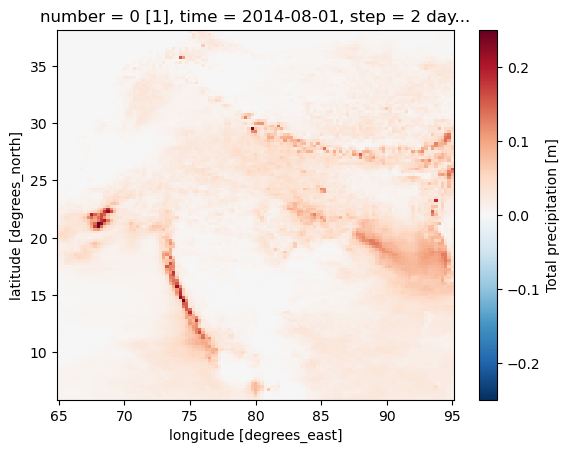

In [7]:
date_str = '2014-08-01'
hres_test.sel(latitude=slice(latmax, latmin), longitude=slice(lonmin, lonmax)).sel(time=date_str).isel(step=11)['tp'].plot()
hres_test.sel(latitude=slice(latmax, latmin), longitude=slice(lonmin, lonmax)).sel(time=date_str).isel(step=11)['tp'].step

In [8]:
eval_targets = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{date_str} 00:00:00.nc')
eval_targets

/tmp/ipykernel_3422233/3321281440.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  eval_targets = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{date_str} 00:00:00.nc')


<xarray.Dataset> Size: 606MB
Dimensions:                  (batch: 1, time: 28, lat: 181, lon: 360, level: 13)
Coordinates:
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 104B 50 100 150 200 ... 850 925 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B ...
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float32 7MB ...
    mean_sea_level_pressure  (batch, time, lat, lon) float32 7MB ...
    10m_v_component_of_wind  (batch, time, lat, lon) float32 7MB ...
    10m_u_component_of_wind  (batch, time, lat, lon) float32 7MB ...
    total_precipitation_6hr  (batch, time, lat, lon) float32 7MB ...
    temperature              (batch, time, level, lat, lon) float32 95MB ...
    geopotential             (batch, time, level, lat, lon) float32 95MB ...
    u_component_of_wind      (batch, time, level, lat, lon) float32 95MB ...
    v_component_of_wind      (batch, time, level, lat, lon) float32 95MB ...
    vertical_velocity        (batch, time, level, lat, lon) float32 95MB ...
    specific_humidity        (batch, time, level, lat, lon) float32 95MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-06T09:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

/tmp/ipykernel_4086406/290796664.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  eval_targets = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{date_str} 00:00:00.nc')


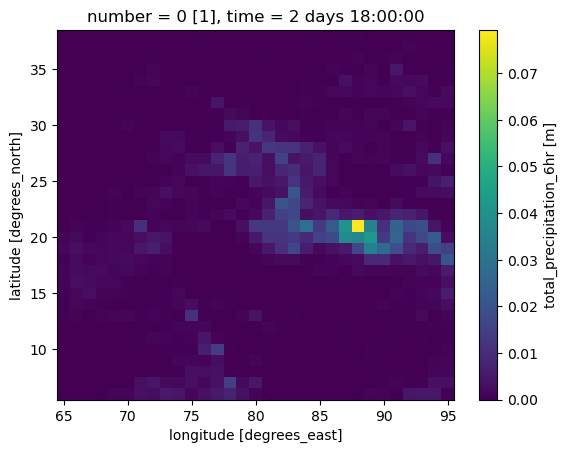

In [10]:
eval_targets = xr.open_dataset(f'/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{date_str} 00:00:00.nc')
eval_targets['total_precipitation_6hr'].sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).isel(time=10).plot()

In [11]:
print(eval_targets)

<xarray.Dataset> Size: 606MB
Dimensions:                  (batch: 1, time: 28, lat: 181, lon: 360, level: 13)
Coordinates:
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 104B 50 100 150 200 ... 850 925 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B ...
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float32 7MB ...
    mean_sea_level_pressure  (batch, time, lat, lon) float32 7MB ...
    10m_v_component_of_wind  (batch, time, lat, lon) float32 7MB ...
    10m_u_component_of_wind  (batch, time, lat, lon) float32 7MB ...
    total_precipitation_6hr  (batch, time, lat, lon) float32 7MB ...
    temperature              (batch, time, level, lat, lon) float32 95MB ...
    geopotential             (batch, 

In [20]:
def extract_hres_date(path):
    parts = path.split('_')
    # print(parts)
    year = 2014  # fixed, or extract if you want dynamic
    month = int(parts[5])
    day = int(parts[6])
    return datetime(year, month, day)


hres_file_list = sorted(glob.glob(f"/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/*.grib"))
hres_files_map = {extract_hres_date(p): p for p in hres_file_list}
hres_files_map

{datetime.datetime(2014, 8, 10, 0, 0): '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_10_ppt_6hourly.grib',
 datetime.datetime(2014, 8, 11, 0, 0): '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_11_ppt_6hourly.grib',
 datetime.datetime(2014, 8, 12, 0, 0): '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_12_ppt_6hourly.grib',
 datetime.datetime(2014, 8, 13, 0, 0): '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_13_ppt_6hourly.grib',
 datetime.datetime(2014, 8, 14, 0, 0): '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_14_ppt_6hourly.grib',
 datetime.datetime(2014, 8, 15, 0, 0): '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_15_ppt_6hourly.grib',
 datetime.datetime(2014, 8, 16, 0, 0): '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_16_ppt_6hourly.grib',
 datetime.dat

In [21]:
mykey = list(hres_files_map.keys())[0]
mykey, hres_files_map[mykey]

(datetime.datetime(2014, 8, 10, 0, 0),
 '/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_10_ppt_6hourly.grib')

In [24]:
hres_predictions = None
hres_file_path = hres_files_map.get(mykey)
hres_file_path

'/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2014/hres_2014_8_10_ppt_6hourly.grib'

In [27]:
eval_targets = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_2024-08-10 00:00:00.nc')

/tmp/ipykernel_3667164/879816711.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  eval_targets = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_2024-08-10 00:00:00.nc')


In [28]:
models_to_eval = {}

hres_ds = xr.open_dataset(hres_file_path, engine='cfgrib')
hres_regridded = regrid_hres_fine_to_coarse(hres_ds, variable='tp', coarse_resolution=1.0)
# Align time dimension with Graphcast targets
hres_predictions = hres_regridded.drop_vars({'time'}).rename({'step': 'time'}).isel(time=slice(1,None)).assign_coords(time=eval_targets.time)
models_to_eval['HRES'] = hres_predictions

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built


In [47]:
print(hres_ds)

<xarray.Dataset> Size: 283MB
Dimensions:     (step: 29, values: 2140702)
Coordinates:
    number      int64 8B 0
    time        datetime64[ns] 8B 2014-08-10
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B 0.0
    latitude    (values) float64 17MB 89.89 89.89 89.89 ... -89.89 -89.89 -89.89
    longitude   (values) float64 17MB 0.0 20.0 40.0 60.0 ... 300.0 320.0 340.0
    valid_time  (step) datetime64[ns] 232B 2014-08-10 ... 2014-08-17
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 248MB 0.0 0.0 0.0 ... 0.0003052 0.0003052
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-20T20:07 GRIB to CDM+CF v

In [40]:
hres_predictions

<xarray.DataArray 'tp' (time: 28, lat: 181, lon: 360)> Size: 7MB
array([[[3.43322754e-05, 3.43322754e-05, 3.43322754e-05, ...,
         3.43322754e-05, 3.43322754e-05, 3.43322754e-05],
        [2.67028809e-05, 2.67028809e-05, 2.67028809e-05, ...,
         2.28881836e-05, 2.67028809e-05, 2.67028809e-05],
        [1.52587891e-05, 1.52587891e-05, 1.52587891e-05, ...,
         1.14440918e-05, 1.52587891e-05, 1.52587891e-05],
        ...,
        [5.72204590e-05, 5.72204590e-05, 5.72204590e-05, ...,
         4.95910645e-05, 5.72204590e-05, 5.72204590e-05],
        [1.02996826e-04, 1.02996826e-04, 1.02996826e-04, ...,
         9.91821289e-05, 1.02996826e-04, 1.02996826e-04],
        [1.33514404e-04, 1.33514404e-04, 1.33514404e-04, ...,
         1.33514404e-04, 1.33514404e-04, 1.33514404e-04]],

       [[1.06811523e-04, 1.06811523e-04, 1.06811523e-04, ...,
         1.06811523e-04, 1.06811523e-04, 1.06811523e-04],
        [3.81469727e-05, 3.81469727e-05, 3.81469727e-05, ...,
         3.81469727e-05, 3.81469727e-05, 3.81469727e-05],
        [1.52587891e-05, 1.52587891e-05, 1.52587891e-05, ...,
         1.52587891e-05, 1.52587891e-05, 1.52587891e-05],
...
        [4.91333008e-03, 4.91333008e-03, 4.91333008e-03, ...,
         5.03540039e-03, 4.91333008e-03, 4.91333008e-03],
        [5.00488281e-03, 5.00488281e-03, 5.00488281e-03, ...,
         5.88989258e-03, 5.00488281e-03, 5.00488281e-03],
        [7.17163086e-03, 7.17163086e-03, 7.17163086e-03, ...,
         7.17163086e-03, 7.17163086e-03, 7.17163086e-03]],

       [[2.74658203e-04, 2.74658203e-04, 2.74658203e-04, ...,
         2.74658203e-04, 2.74658203e-04, 2.74658203e-04],
        [1.22070312e-04, 1.22070312e-04, 1.22070312e-04, ...,
         1.22070312e-04, 1.22070312e-04, 1.22070312e-04],
        [6.10351562e-05, 6.10351562e-05, 6.10351562e-05, ...,
         6.10351562e-05, 6.10351562e-05, 6.10351562e-05],
        ...,
        [5.12695312e-03, 5.12695312e-03, 5.12695312e-03, ...,
         5.27954102e-03, 5.12695312e-03, 5.12695312e-03],
        [5.15747070e-03, 5.15747070e-03, 5.15747070e-03, ...,
         6.07299805e-03, 5.15747070e-03, 5.15747070e-03],
        [7.35473633e-03, 7.35473633e-03, 7.35473633e-03, ...,
         7.35473633e-03, 7.35473633e-03, 7.35473633e-03]]], dtype=float32)
Coordinates:
    number      int64 8B ...
    surface     float64 8B 0.0
    valid_time  (time) datetime64[ns] 224B 2014-08-10T06:00:00 ... 2014-08-17
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * time        (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
    expver      (time) <U4 448B ...
Attributes: (12/23)
    GRIB_paramId:                    228
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             2140702
    GRIB_typeOfLevel:                surface
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_totalNumber:                0
    GRIB_units:                      m
    long_name:                       Total precipitation
    units:                           m
    standard_name:                   unknown
    regrid_method:                   nearest_s2d

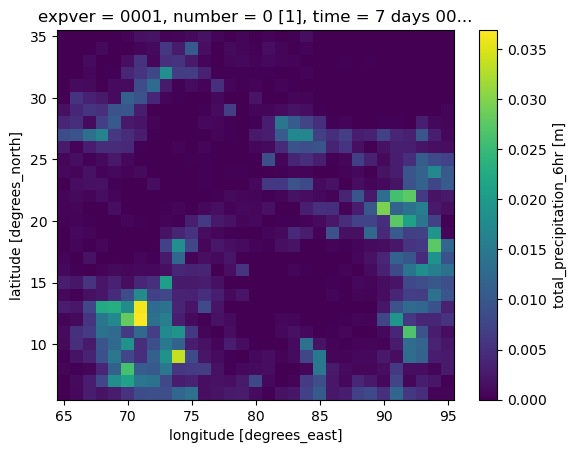

In [39]:
eval_targets.isel(time=-1)['total_precipitation_6hr'].sel(lat=slice(6, 35), lon=slice(65, 95)).plot()

In [ ]:
for init_date in tqdm(initialization_dates, desc="Evaluating Forecasts"):
    hres_predictions = None
    hres_file_path = hres_files_map.get(init_date.to_pydatetime().replace(hour=0, minute=0, second=0, microsecond=0))
    if hres_file_path:
        try:
            logging.debug(f"Processing HRES file: {hres_file_path}")
            hres_ds = xr.open_dataset(hres_file_path, engine='cfgrib')
            hres_regridded = regrid_hres_fine_to_coarse(hres_ds, variable='tp', coarse_resolution=1.0)
            # Align time dimension with Graphcast targets
            hres_predictions = hres_regridded.drop_vars({'time'}).rename({'step': 'time'}).isel(time=slice(1,None)).assign_coords(time=eval_targets.time)
            models_to_eval['HRES'] = hres_predictions
        except Exception as e:
            logging.warning(f"Failed to process HRES file {hres_file_path}: {e}")
    else:
        logging.warning(f"No HRES file found for init date {init_date}")


In [18]:
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import glob
import os
import xesmf as xe

def load_ground_truth_file(filepath):
    """Load and extract precipitation data from ground truth file"""
    ds = xr.open_dataset(filepath)
    # Extract precipitation data and remove batch dimension
    precip = ds['total_precipitation_6hr'].squeeze('batch')
    return precip

def create_regridder(forecast_ds, truth_ds):
    """
    Create xESMF regridder to interpolate forecast data to ground truth grid
    """
    # Create grid datasets for xESMF
    # HRES forecast grid (source - finer resolution)
    forecast_grid = xr.Dataset({
        'lat': (['lat'], forecast_ds.latitude.values),
        'lon': (['lon'], forecast_ds.longitude.values),
    })
    
    # Ground truth grid (target - coarser resolution)
    truth_grid = xr.Dataset({
        'lat': (['lat'], truth_ds.lat.values),
        'lon': (['lon'], truth_ds.lon.values),
    })
    
    # Create regridder (bilinear interpolation)
    regridder = xe.Regridder(
        forecast_grid, 
        truth_grid, 
        'bilinear',
        periodic=True  # Longitude wraps around
    )
    
    return regridder

def regrid_forecast_data(forecast_data, regridder):
    """
    Regrid forecast data using xESMF regridder
    """
    # Rename coordinates to match what xESMF expects
    forecast_renamed = forecast_data.rename({'latitude': 'lat', 'longitude': 'lon'})
    
    # Apply regridding
    regridded = regridder(forecast_renamed)
    
    return regridded

def calculate_rmse(forecast, truth):
    """Calculate RMSE between forecast and truth, handling NaN values"""
    # Flatten arrays for easier computation
    forecast_flat = forecast.values.flatten()
    truth_flat = truth.values.flatten()
    
    # Mask where both have valid data
    valid_mask = ~(np.isnan(forecast_flat) | np.isnan(truth_flat))
    
    if not np.any(valid_mask):
        return np.nan
    
    # Calculate RMSE only for valid points
    diff = forecast_flat[valid_mask] - truth_flat[valid_mask]
    rmse = np.sqrt(np.mean(diff**2))
    return rmse



In [19]:
# Load the HRES forecast dataset
print("Loading HRES forecast data...")
hres_ds = xr.open_dataset(hres_forecasts_2014_path)  # Update with your actual filename

# Get forecast precipitation data
forecast_tp = hres_ds['tp']

# Load a sample ground truth file to create the regridder
print("Setting up regridder...")
sample_gt_files = glob.glob('/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_*.nc')
if not sample_gt_files:
    print("Error: No ground truth files found with pattern 'target_init_*.nc'")
    exit()

sample_gt = load_ground_truth_file(sample_gt_files[0])

# Create regridder (from fine HRES grid to coarse ground truth grid)
regridder = create_regridder(forecast_tp.isel(time=0, step=0), sample_gt.isel(time=0))

# Initialize results list
results = []

Loading HRES forecast data...
Setting up regridder...


/tmp/ipykernel_4086406/4290967234.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  hres_ds = xr.open_dataset(hres_forecasts_2014_path)  # Update with your actual filename
/tmp/ipykernel_4086406/2965017622.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filepath)


In [20]:
regridder

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_721x1440_181x360_peri.nc 
Reuse pre-computed weights? False 
Input grid shape:           (721, 1440) 
Output grid shape:          (181, 360) 
Periodic in longitude?      True

In [25]:
i = 0
init_time = forecast_tp.time.values[61]
init_time

numpy.datetime64('2014-08-01T00:00:00.000000000')

In [28]:
init_datetime = pd.to_datetime(init_time)
print(f"Processing initialization time {i+1}/{len(forecast_tp.time)}: {init_datetime}")

# Construct ground truth filename
gt_filename = f"/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{init_datetime.strftime('%Y-%m-%d %H:%M:%S')}.nc"

# Check if ground truth file exists
if not os.path.exists(gt_filename):
    print(f"Warning: Ground truth file {gt_filename} not found. Skipping.")
    

# Load ground truth data for this initialization
try:
    gt_precip = load_ground_truth_file(gt_filename)
except Exception as e:
    print(f"Error loading {gt_filename}: {e}. Skipping.")
    
gt_precip

Processing initialization time 1/92: 2014-08-01 00:00:00


/tmp/ipykernel_4086406/2965017622.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filepath)


<xarray.DataArray 'total_precipitation_6hr' (time: 28, lat: 181, lon: 360)> Size: 7MB
[1824480 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B ...
  * time     (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
Attributes:
    source:             IMERG daily precipitation converted to 6‑hourly accum...
    original_source:    GPM IMERG Final Precipitation L3 1 day 0.1°×0.1° V07
    conversion_method:  Daily rate (mm/day) → 6‑hr accum. (m), ERA5 used wher...
    units:              m

In [31]:
forecast_init

<xarray.DataArray 'tp' (step: 29, latitude: 721, longitude: 1440)> Size: 241MB
[30108960 values with dtype=float64]
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B 2014-08-01
  * step        (step) timedelta64[ns] 232B 0 days 00:00:00 ... 7 days 00:00:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 232B ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes: (12/31)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown

In [30]:
len(forecast_init.step.values), len(gt_precip.time.values)

(29, 28)

In [48]:

# Get forecast data for this initialization time
forecast_init = forecast_tp.sel(time=init_time)

# Process each lead time step
for j, step in enumerate(forecast_init.step.values[1:]):

    step_hours = pd.to_timedelta(step).total_seconds() / 3600
    
    # Check if we have corresponding ground truth data
    if j >= len(gt_precip.time):
        print(f"Warning: No ground truth data for step {j} ({step_hours}h). Skipping.")
        
    
    # Get forecast and truth data for this step
    forecast_step = forecast_init.sel(step=step)
    truth_step = gt_precip.isel(time=j)
    

    # Regrid forecast data to ground truth grid (coarse grid)
    forecast_regridded = regrid_forecast_data(forecast_step, regridder)
    
    # Calculate RMSE)
    rmse = calculate_rmse(forecast_regridded, truth_step)
    
    # Store results
    results.append({
        'initialization_time': init_datetime,
        'lead_time_hours': step_hours,
        'step_index': j,
        'rmse': rmse,
        'valid_time': init_datetime + pd.to_timedelta(step)
    })
    
    # print(f"  Step {j} ({step_hours}h): RMSE = {rmse:.6f}")


In [50]:

# Process each forecast initialization time
from tqdm.notebook import tqdm
for i, init_time in tqdm(enumerate(forecast_tp.time.values)):
    init_datetime = pd.to_datetime(init_time)
    # print(f"Processing initialization time {i+1}/{len(forecast_tp.time)}: {init_datetime}")
    
    # Construct ground truth filename
    gt_filename = f"/Datastorage/saptarishi.dhanuka_asp25/rolled_out_preds/target_init_{init_datetime.strftime('%Y-%m-%d %H:%M:%S')}.nc"
    
    # Check if ground truth file exists
    if not os.path.exists(gt_filename):
        # print(f"Warning: Ground truth file {gt_filename} not found. Skipping.")
        continue
    
    # Load ground truth data for this initialization
    try:
        gt_precip = load_ground_truth_file(gt_filename)
    except Exception as e:
        print(f"Error loading {gt_filename}: {e}. Skipping.")
        continue
    
    # Get forecast data for this initialization time
    forecast_init = forecast_tp.sel(time=init_time)
    
    # Process each lead time step
    for j, step in enumerate(forecast_init.step.values[1:]):
        step_hours = pd.to_timedelta(step).total_seconds() / 3600
        
        # Check if we have corresponding ground truth data
        if j >= len(gt_precip.time):
            print(f"Warning: No ground truth data for step {j} ({step_hours}h). Skipping.")
            continue
        
        # Get forecast and truth data for this step
        forecast_step = forecast_init.sel(step=step)
        truth_step = gt_precip.isel(time=j)
        
        try:
            # Regrid forecast data to ground truth grid (coarse grid)
            forecast_regridded = regrid_forecast_data(forecast_step, regridder)
            
            # Calculate RMSE
            rmse = calculate_rmse(forecast_regridded, truth_step)
            
            # Store results
            results.append({
                'initialization_time': init_datetime,
                'lead_time_hours': step_hours,
                'step_index': j,
                'rmse': rmse,
                'valid_time': init_datetime + pd.to_timedelta(step)
            })
            
            # print(f"  Step {j} ({step_hours}h): RMSE = {rmse:.6f}")
            
        except Exception as e:
            print(f"Error processing step {j}: {e}")
            continue

# Clean up regridder
# regridder.clean_weight_file()

# Convert results to DataFrame and save
if results:
    df = pd.DataFrame(results)
    
    # Sort by initialization time and lead time
    # df = df.sort_values(['initialization_time', 'lead_time_hours'])
    
    # Save to CSV
    output_filename = 'precipitation_rmse_results_hres20140801_20140830.csv'
    df.to_csv(output_filename, index=False)
    
    print(f"\nResults saved to {output_filename}")
    print(f"Total number of RMSE calculations: {len(df)}")
    print(f"Average RMSE: {df['rmse'].mean():.6f}")
    print(f"RMSE range: {df['rmse'].min():.6f} - {df['rmse'].max():.6f}")
    
    # Display sample results
    print("\nSample results:")
    print(df.head(10))
    
    # Show some statistics by lead time
    print("\nRMSE statistics by lead time:")
    lead_time_stats = df.groupby('lead_time_hours')['rmse'].agg(['count', 'mean', 'std', 'min', 'max'])
    print(lead_time_stats.head(10))
    
else:
    print("No results calculated. Please check your data files and paths.")



0it [00:00, ?it/s]

/tmp/ipykernel_4086406/2965017622.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filepath)
/tmp/ipykernel_4086406/2965017622.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filepath)
/tmp/ipykernel_4086406/2965017622.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filepath)
/tmp/ipykernel_4086406/2965017622.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timed


Results saved to precipitation_rmse_results_hres20140801_20140830.csv
Total number of RMSE calculations: 4480
Average RMSE: 0.015814
RMSE range: 0.001852 - 0.029905

Sample results:
  initialization_time  lead_time_hours  step_index      rmse  \
0          2014-08-01              0.0           0  0.002255   
1          2014-08-01              6.0           1  0.002205   
2          2014-08-01             12.0           2  0.003109   
3          2014-08-01             18.0           3  0.004785   
4          2014-08-01             24.0           4  0.005796   
5          2014-08-01             30.0           5  0.006807   
6          2014-08-01             36.0           6  0.007912   
7          2014-08-01             42.0           7  0.009406   
8          2014-08-01             48.0           8  0.010411   
9          2014-08-01             54.0           9  0.011420   

           valid_time  
0 2014-08-01 00:00:00  
1 2014-08-01 06:00:00  
2 2014-08-01 12:00:00  
3 2014-08-01 18: